## Імпорт необхідних бібліотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")

## Завантаження та Data Cleaning

In [3]:
def load_and_clean_data(url):
    cols = [
        'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
        'marital-status', 'occupation', 'relationship', 'race', 'sex', 
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
    ]
    
    # Завантаження. sep=',\s*' для коректної обробки пробілів у цьому CSV
    df = pd.read_csv(url, names=cols, sep=',\s*', na_values='?', engine='python')
    
    # Перевірка на наявність даних
    if df.empty:
        raise RuntimeError("Датасет не вдалося завантажити: отримано порожній об'єкт.")
        
    # Перетворення типів на самому початку
    numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    print(f"Початкова кількість записів: {len(df)}")

    # Data Cleaning
    df_clean = df.dropna().reset_index(drop=True)
    print(f"Знайдено та видалено пропусків: {len(df) - len(df_clean)}")
    print(f"Кількість записів після очищення: {len(df_clean)}")
    return df_clean

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df_adult = load_and_clean_data(dataset_url)
display(df_adult.head())

Початкова кількість записів: 32561
Знайдено та видалено пропусків: 2399
Кількість записів після очищення: 30162


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Графіки залежності (Scatter Plot та Line Plot) з багатовимірністю
Будуємо графіки залежності одного числового атрибута від іншого. 

Дослідимо зв'язок між **віком (age)** та **кількістю робочих годин на тиждень (hours-per-week)**. 


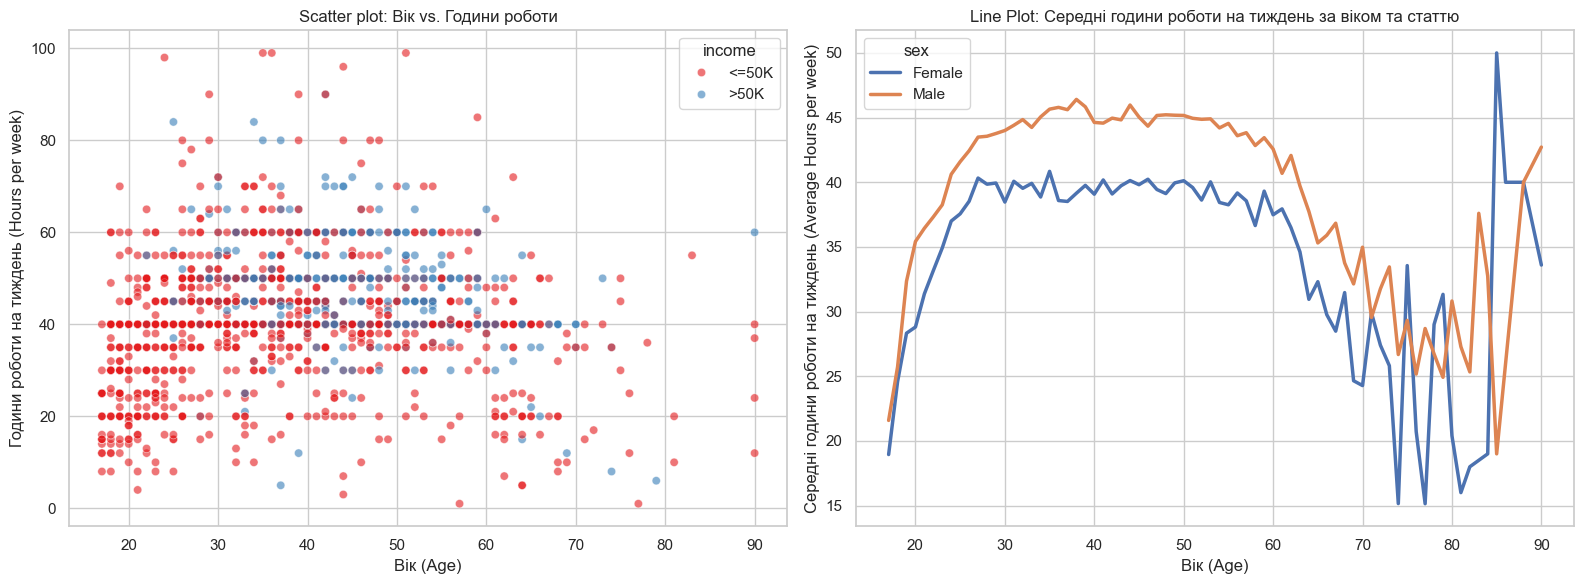

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Графік 1: Scatter plot для віку та годин роботи на тиждень
sns.scatterplot(data=df_adult.sample(2000), x='age', y='hours-per-week', hue='income', alpha=0.6, palette='Set1', ax=axes[0])
axes[0].set_title('Scatter plot: Вік vs. Години роботи')
axes[0].set_xlabel('Вік (Age)')
axes[0].set_ylabel('Години роботи на тиждень (Hours per week)')

# Графік 2: Line plot для середніх годин роботи на тиждень за віком та статтю
age_sex_hours = df_adult.groupby(['age', 'sex'])['hours-per-week'].mean().reset_index()

sns.lineplot(data=age_sex_hours, x='age', y='hours-per-week', hue='sex', linewidth=2.5, ax=axes[1])
axes[1].set_title('Line Plot: Середні години роботи на тиждень за віком та статтю')
axes[1].set_xlabel('Вік (Age)')
axes[1].set_ylabel('Середні години роботи на тиждень (Average Hours per week)')

plt.tight_layout()
plt.show()

## Гістограма з розподілом на 5 заданих діапазонів

Ми проаналізуємо розподіл віку (`age`) серед працівників датасету. Для цього визначимо 5 життєвих/кар'єрних етапів:
1. **17-25:** Молодь (старт кар'єри)
2. **25-35:** Ранній кар'єрний вік
3. **35-45:** Середина кар'єри
4. **45-55:** Пік кар'єри
5. **55-90:** Передпенсійний та пенсійний вік

C:\Users\_miyadi._.z_\AppData\Local\Temp\ipykernel_13180\3017948493.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette="viridis")


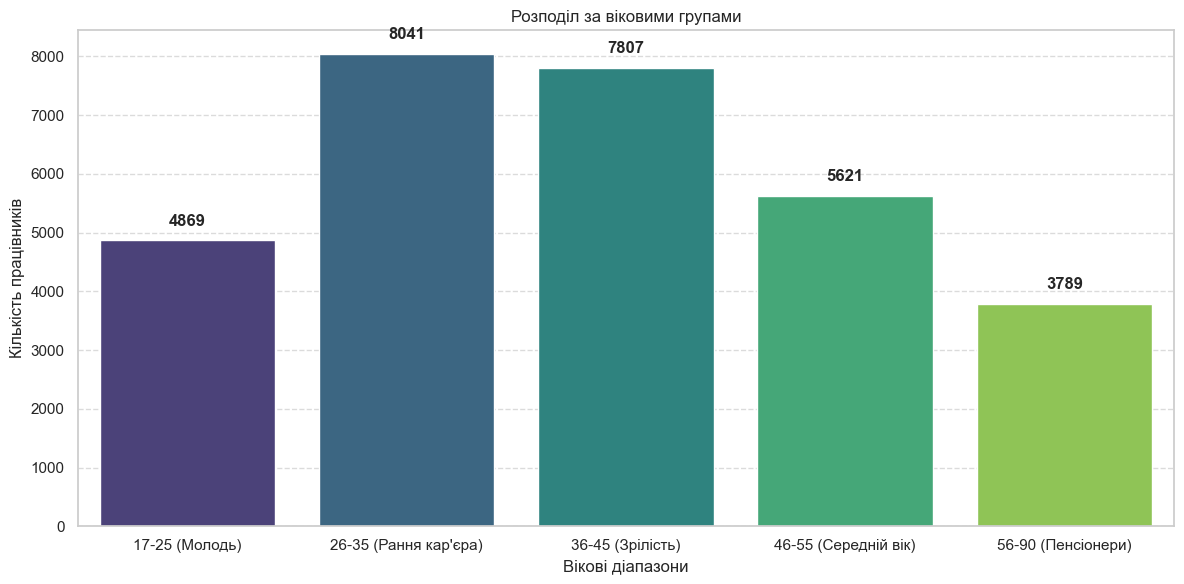

In [18]:
bins = [17, 25, 35, 45, 55, 90]
labels = ['17-25 (Молодь)', '26-35 (Рання кар\'єра)', '36-45 (Зрілість)', '46-55 (Середній вік)', '56-90 (Пенсіонери)']

df_adult['age_group'] = pd.cut(df_adult['age'], bins=bins, labels=labels, include_lowest=True, right=False)

age_counts = df_adult['age_group'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette="viridis")

for index, value in enumerate(age_counts.values):
    plt.text(index, value + 200, str(value), ha='center', va='bottom', fontweight='bold')

plt.title('Розподіл за віковими групами')
plt.xlabel('Вікові діапазони', fontsize=12)
plt.ylabel('Кількість працівників', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Збудувати графіки, використовуючи приклади, наведені у 
https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 
**Побудуємо наступні графіки:**
1. **Boxplot:** Розподіл робочих годин (`hours-per-week`) залежно від рівня освіти (`education`) з поділом за доходом (`income`). Це дозволить побачити медіану, квартилі та викиди (аномалії).
2. **Heatmap (Теплова карта):** Показує матрицю кореляції Пірсона між усіма числовими атрибутами.
3. **Pairplot:** Матриця діаграм розсіяння для обраних числових змінних з поділом за рівнем доходу.


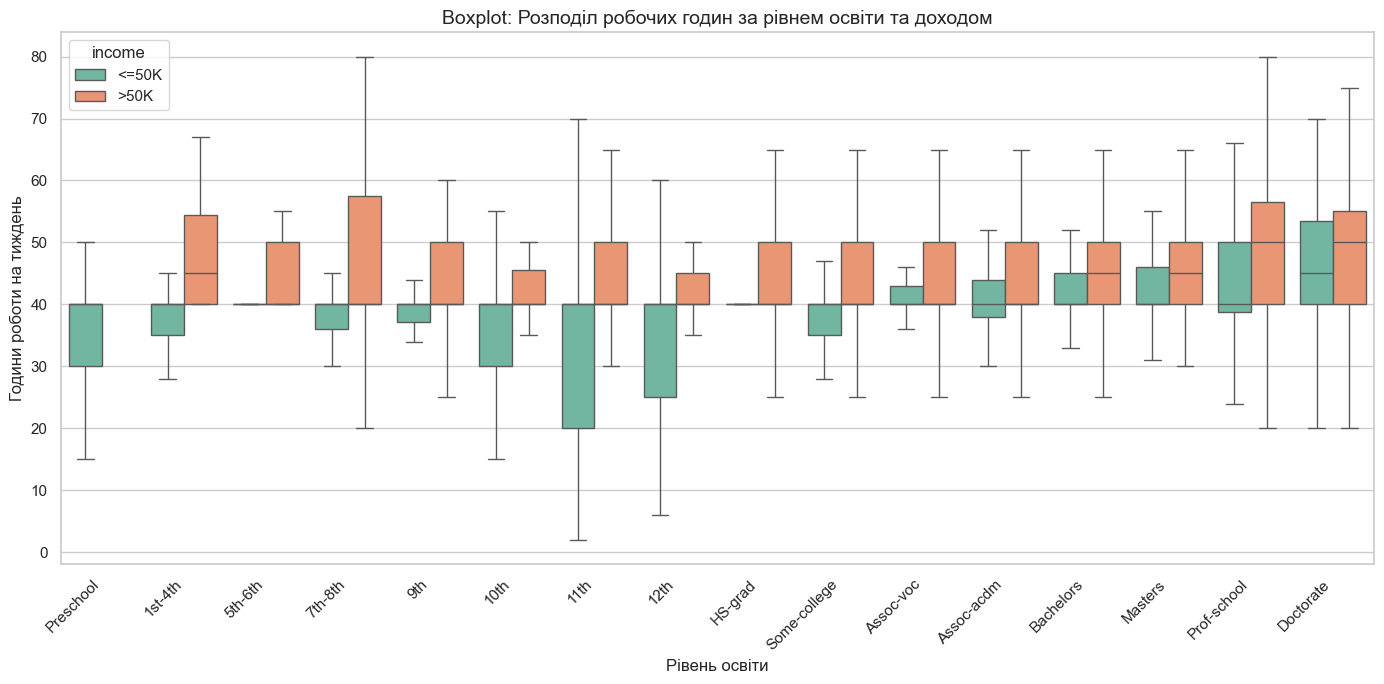

In [4]:
# Boxplot (Багатовимірний: Освіта + Години + Дохід)
plt.figure(figsize=(14, 7))
education_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 
                   'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']

sns.boxplot(
    data=df_adult, 
    x='education', 
    y='hours-per-week', 
    hue='income',
    order=education_order,
    palette='Set2',
    showfliers=False
)
plt.title('Boxplot: Розподіл робочих годин за рівнем освіти та доходом', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Рівень освіти')
plt.ylabel('Години роботи на тиждень')
plt.tight_layout()
plt.show()

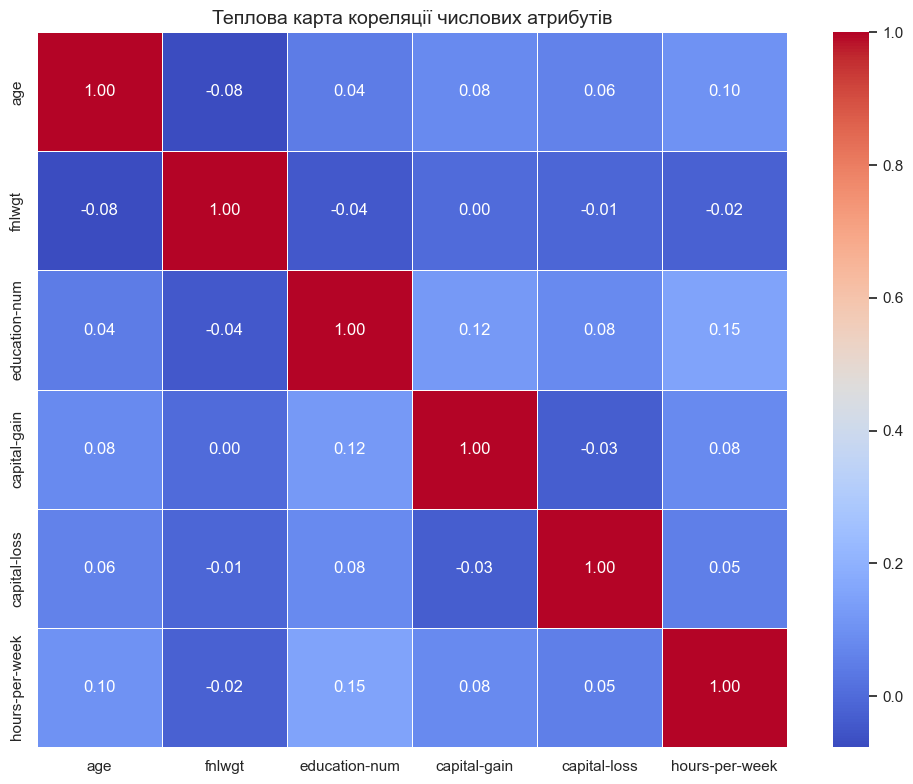

In [5]:
# Heatmap (Теплова карта кореляції)
plt.figure(figsize=(10, 8))
numeric_df = df_adult.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix, 
    annot=True,        
    cmap='coolwarm',   
    fmt=".2f",         
    linewidths=0.5
)
plt.title('Теплова карта кореляції числових атрибутів', fontsize=14)
plt.tight_layout()
plt.show()

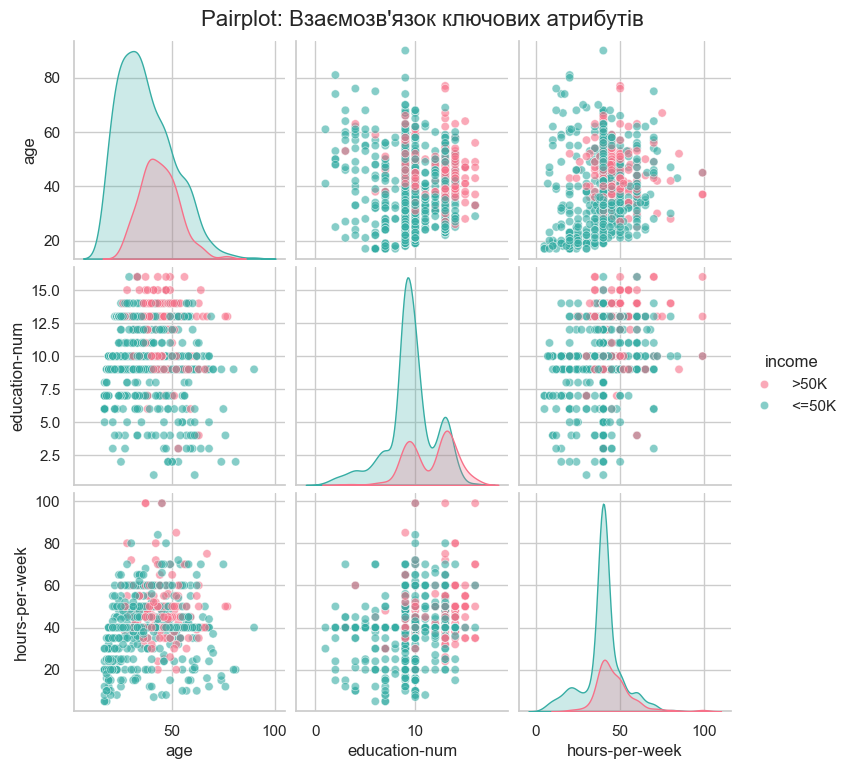

In [7]:
# Pairplot (Матриця графіків для ключових ознак)
cols_for_pairplot = ['age', 'education-num', 'hours-per-week', 'income']

sns.pairplot(
    df_adult[cols_for_pairplot].sample(1000, random_state=42), 
    hue='income', 
    palette='husl',
    plot_kws={'alpha': 0.6}
)
plt.suptitle("Pairplot: Взаємозв'язок ключових атрибутів", y=1.02, fontsize=16)
plt.show()